# Ddareungi Demand Forecasting — Weekend SARIMA/ARIMAX Pipeline

## 1. 라이브러리 로드 및 설정

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 통계 모델
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error

# auto_arima
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
    print("pmdarima loaded successfully")
except ImportError:
    HAS_PMDARIMA = False
    print("[Warning] pmdarima not found -> pip install pmdarima")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

pmdarima loaded successfully


In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))


In [3]:
# pip install pmdarima

## 2. 설정값 및 데이터 로드

In [ ]:
from src.config import DATA_DIR, SEASONAL_PERIOD, TEST_DAYS, TARGET_RENT_ID, LONG_MISSING, ALPHA


In [ ]:
from src.utils import (
    load_filtered_csvs, make_series, load_weather,
    adf_test, diagnose_residuals, asymmetric_rmse, evaluate_forecast,
)

df_raw = load_filtered_csvs(DATA_DIR)
print(f"전체 데이터: {df_raw.shape}")
print(f"날짜 범위: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")
print(f"정류소 수: {df_raw['RENT_ID'].nunique()}개")
df_raw.head()


## 3. 데이터 전처리
**결측치 처리 전략** (`missing_value_report.md` 기준)
- 단기 (1~3일): 선형 보간
- 중기 (4~14일): 동일 요일+시간대 평균 대체  
- 장기 (15일 이상): NaN 유지 → 학습 윈도우에서 제외

In [ ]:
series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)


In [7]:
# Weekend / Weekday split
series_weekday = series[series.index.dayofweek < 5]
series_weekend = series[series.index.dayofweek >= 5]
print(f"Weekday data: {len(series_weekday):,} hours")
print(f"Weekend data: {len(series_weekend):,} hours")

Weekday data: 31,293 hours
Weekend data: 12,528 hours


In [8]:
# Train / Test Split — Weekend data
target_series = series_weekend.dropna()

test_hours = TEST_DAYS * 24
train = target_series.iloc[:-test_hours]
test  = target_series.iloc[-test_hours:]

print(f"Train: {train.index[0]} ~ {train.index[-1]} ({len(train):,} hours)")
print(f"Test : {test.index[0]} ~ {test.index[-1]} ({len(test):,} hours)")

Train: 2021-01-02 00:00:00 ~ 2025-09-14 23:00:00 (11,808 hours)
Test : 2025-09-20 00:00:00 ~ 2025-12-28 23:00:00 (720 hours)


## 4. 정상성 검정 — ADF Test
- $H_0$: 단위근 존재 (non-stationary)  
- $H_1$: 단위근 없음 (stationary)  
- p-value < 0.05이면 정상성 확보


In [ ]:
print("=" * 50)
is_stationary = adf_test(train, name=f"Station {TARGET_RENT_ID} (raw)")

if not is_stationary:
    print(f"\nS={SEASONAL_PERIOD} 계절 차분 후 재검정...")
    train_diff = train.diff(SEASONAL_PERIOD).dropna()
    print("=" * 50)
    adf_test(train_diff, name=f"Station {TARGET_RENT_ID} (after seasonal diff)")
else:
    train_diff = train


## 5. ACF / PACF 시각화
차수 후보 파악: ACF → MA 차수, PACF → AR 차수


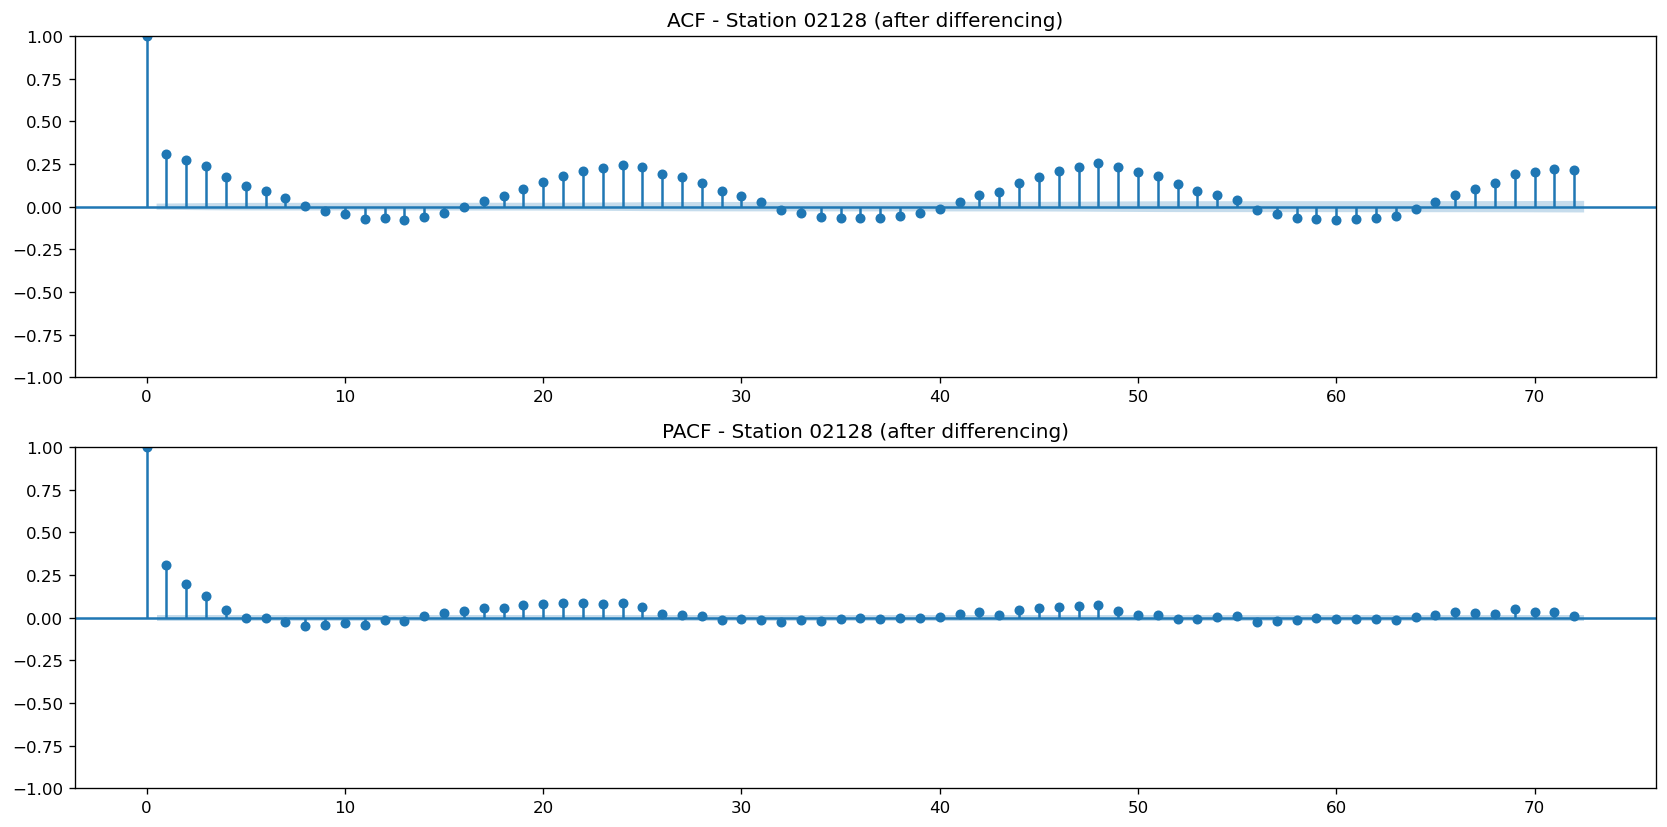

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff.dropna(), lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (after differencing)")
plot_pacf(train_diff.dropna(), lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (after differencing)")
plt.tight_layout()
plt.show()

## 6. SARIMA 모델 적합
`auto_arima`로 AIC 기준 최적 차수 자동 선택
계절 주기 **S=24** (시간 단위 데이터 → 하루 주기)


# auto_arima로 최적 차수 선택
if HAS_PMDARIMA:
    print("auto_arima 실행 중 (AIC 기준)...")
    auto_model = pm.auto_arima(
        train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        start_p=0, max_p=2,   # AR 차수 최대 2
        start_q=0, max_q=2,   # MA 차수 최대 2
        start_P=0, max_P=1,   # 계절 AR 최대 1
        start_Q=0, max_Q=1,   # 계절 MA 최대 1
        d=0,                  # ADF에서 정상 확인됐으니까 고정
        D=1,                  # 계절 차분 1회
        stepwise=True,
        information_criterion="aic",
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
    )
    order          = auto_model.order
    seasonal_order = auto_model.seasonal_order
    print(f"\n최적 차수: ARIMA{order}x{seasonal_order}")
else:
    # pmdarima 없을 때 기본값
    order          = (1, 0, 1)
    seasonal_order = (1, 1, 1, SEASONAL_PERIOD)
    print(f"기본 차수 사용: ARIMA{order}x{seasonal_order}")

In [11]:
# SARIMA 적합
# auto_arima 대신 ACF/PACF 결과 기반으로 차수 직접 고정


order          = (1, 0, 2)
seasonal_order = (1, 1, 0, SEASONAL_PERIOD)
print(f"Using fixed order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Using fixed order: ARIMA(1, 0, 2)x(1, 1, 0, 24)


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                11808
Model:             SARIMAX(1, 0, 2)x(1, 1, [], 24)   Log Likelihood              -19252.161
Date:                             Sat, 23 May 2026   AIC                          38514.322
Time:                                     00:51:16   BIC                          38551.184
Sample:                                          0   HQIC                         38526.700
                                           - 11808                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7632      0.033     23.142      0.000       0.699       0.828
ma.L1         -0.6815      

## 7. ARIMAX 모델 적합
기상 데이터(기온, 강수량)를 외생변수로 추가  
기상청 데이터 수집 후 `weather.csv`로 저장하여 사용

만약 기상 데이터 처리가 어렵다고, 월별 더미로 돌리기!


In [ ]:
weather_df = load_weather(DATA_DIR)
weather_df.head()


In [13]:
#  train/test 인덱스에 맞춰 자르기

exog_train = weather_df.loc[train.index][["temp"]]
exog_test  = weather_df.loc[test.index][["temp"]]

print("외생변수 shape:", exog_train.shape)
exog_train.head()

외생변수 shape: (11808, 1)


,temp
2021-01-02 00:00:00,-3.4
2021-01-02 01:00:00,-4.1
2021-01-02 02:00:00,-5.0
2021-01-02 03:00:00,-5.8
2021-01-02 04:00:00,-6.3


In [14]:
# ARIMAX 적합
# order          = (1, 0, 1)
# seasonal_order = (0, 1, 1, SEASONAL_PERIOD)
# print(f"Using fixed order: ARIMA{order}x{seasonal_order}")

arimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                11808
Model:             SARIMAX(1, 0, 2)x(1, 1, [], 24)   Log Likelihood              -19227.572
Date:                             Sat, 23 May 2026   AIC                          38467.144
Time:                                     00:51:54   BIC                          38511.379
Sample:                                          0   HQIC                         38481.998
                                           - 11808                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp           0.0245      0.004      6.527      0.000       0.017       0.032
ar.L1          0.7674      

## 8. 잔차 진단
| 검정 | 귀무가설 |
|------|----------|
| Ljung-Box | 잔차에 자기상관 없음 (백색잡음) |
| Jarque-Bera | 잔차가 정규분포를 따름 |
| Shapiro-Wilk | 잔차가 정규분포를 따름 |


  잔차 진단: SARIMA

[Ljung-Box Test] H0: 잔차에 자기상관 없음
        lb_stat      lb_pvalue
10     4.110902   9.422053e-01
20    13.940669   8.334914e-01
48  1510.369287  6.662212e-285
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=9739.6173, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9364, p-value=0.0000
  → 정규성 기각


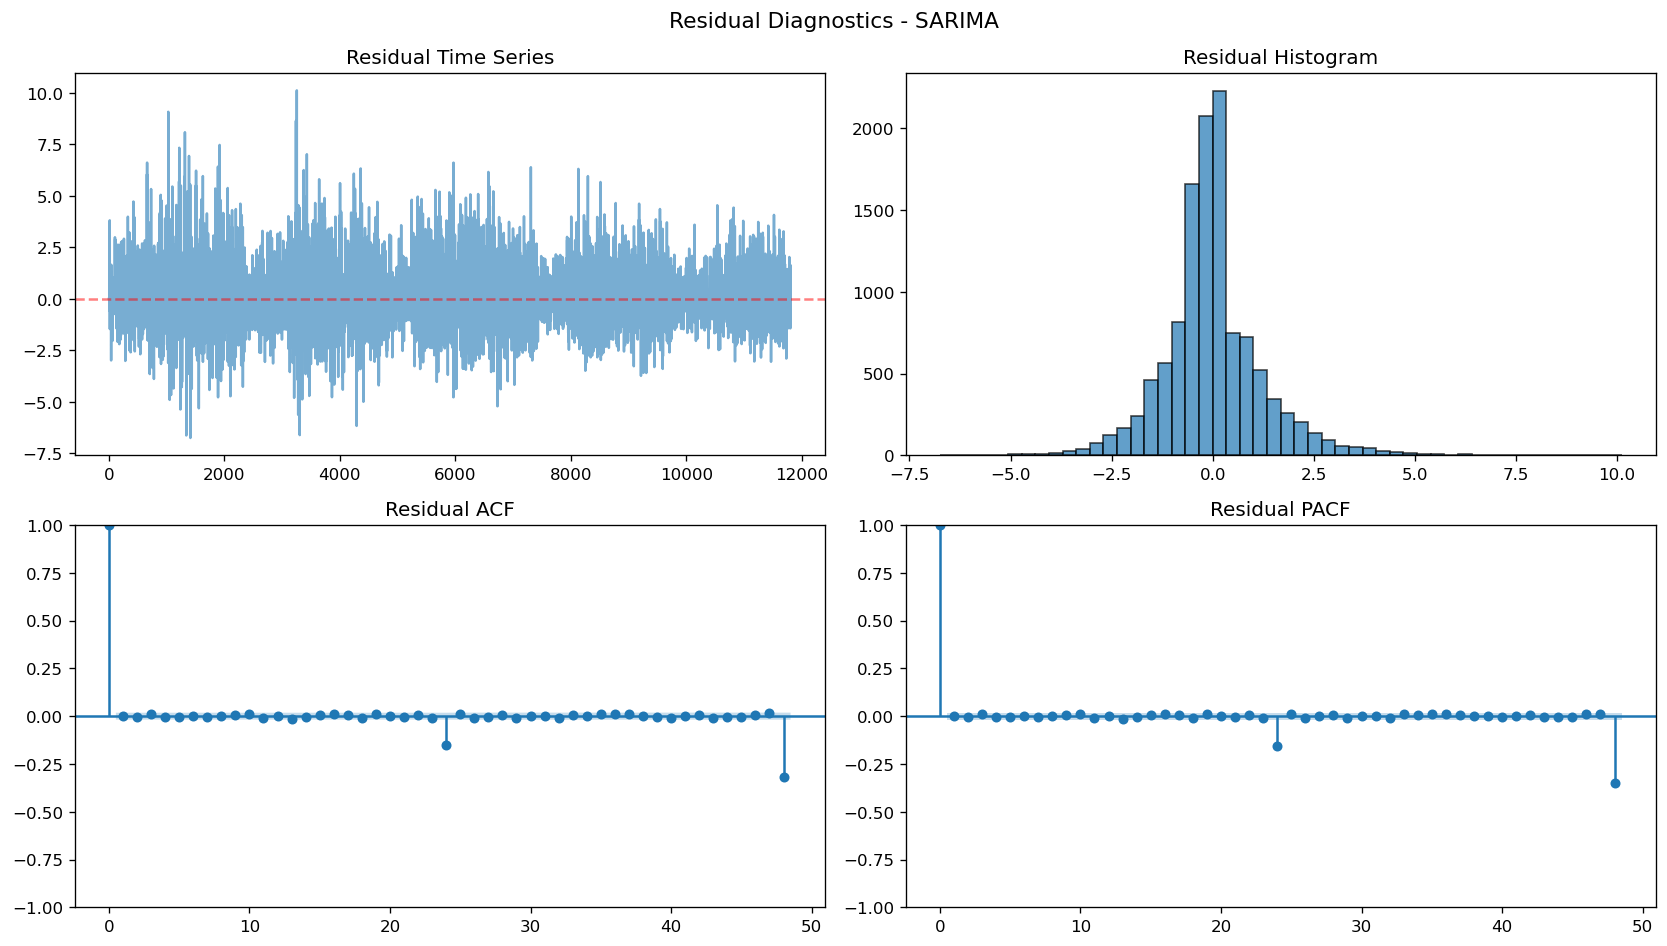

In [16]:
# SARIMA 잔차 진단
diag_sarima = diagnose_residuals(sarima_fit, model_name="SARIMA")

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
        lb_stat      lb_pvalue
10     4.380747   9.285407e-01
20    14.332498   8.132453e-01
48  1513.794616  1.265944e-285
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=9825.4802, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9380, p-value=0.0000
  → 정규성 기각


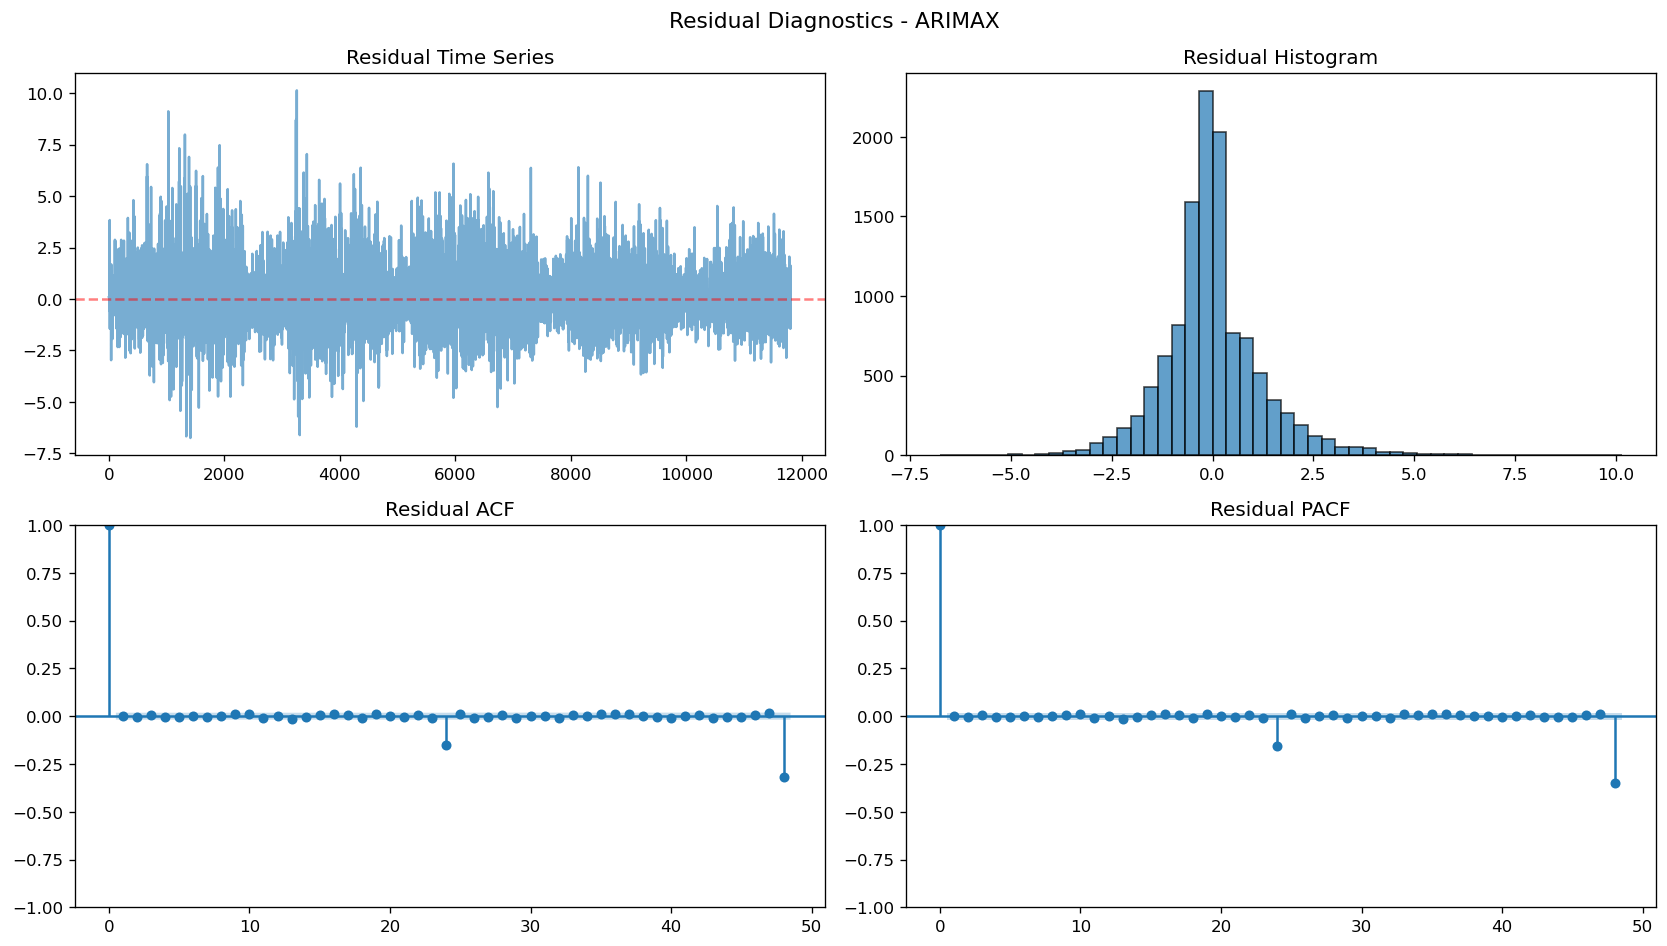

In [17]:
# ARIMAX 잔차 진단
diag_arimax = diagnose_residuals(arimax_fit, model_name="ARIMAX")

## 9. 예측 성능 평가

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 자전거 고갈 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

- $y$: 실제 대여 건수 (CNT)
- $\hat{y}$: 모델이 예측한 대여 건수
- $\alpha > 1$: 과소예측 패널티 가중치 (기본값 $\alpha=2$)


In [ ]:
perf_sarima = evaluate_forecast(sarima_fit, test, model_name="SARIMA", alpha=ALPHA)


In [ ]:
perf_arimax = evaluate_forecast(arimax_fit, test, model_name="ARIMAX",
                                exog_test=exog_test, alpha=ALPHA)


## 10. 모델 성능 비교


              Model Performance Comparison
        RMSE    MAE  Asym.RMSE(α=2.0)  과소예측비율(%)
model                                           
SARIMA  0.83  0.516             1.061       21.2
ARIMAX  0.88  0.618             1.191       71.5


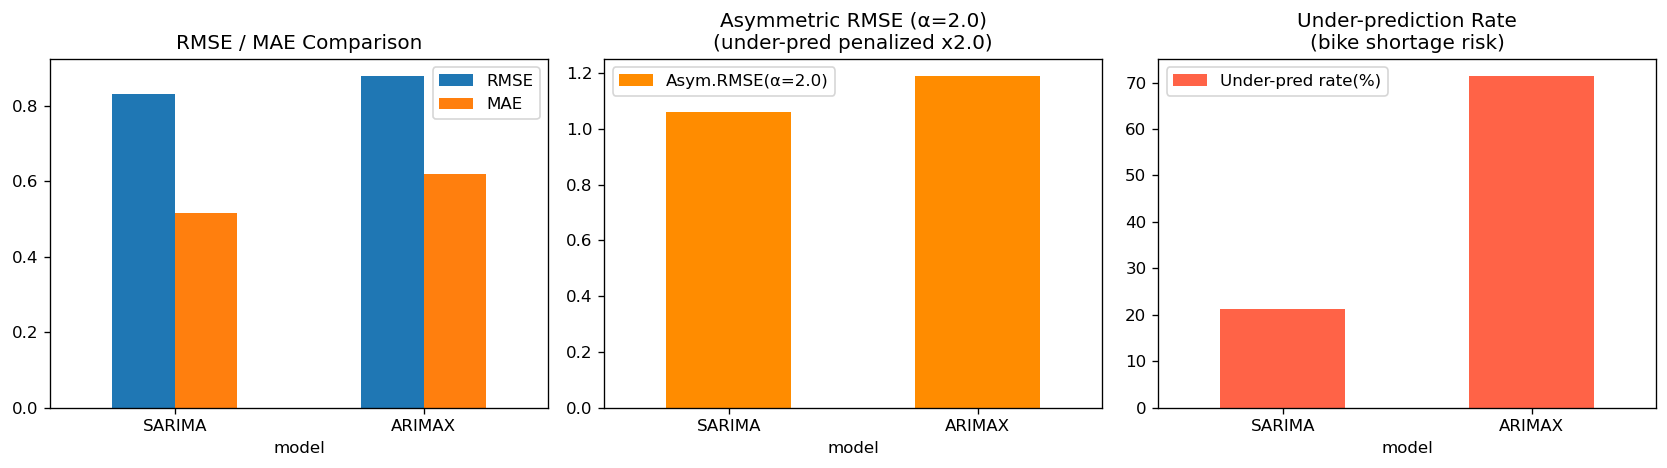

In [21]:
result_df = pd.DataFrame([perf_sarima, perf_arimax]).set_index("model")
print("\n" + "="*55)
print("              Model Performance Comparison")
print("="*55)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(α={ALPHA})"
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=0)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (α={ALPHA})\n(under-pred penalized x{ALPHA})", rot=0, color="darkorange")

result_df[["과소예측비율(%)"]].rename(
    columns={"과소예측비율(%)": "Under-pred rate(%)"}
).plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)", rot=0, color="tomato")

plt.tight_layout()
plt.show()